# K-Means Clustering from Scratch
**Dataset:** 2D Point Cloud Dataset  
**Student ID:** 011320065  
**Objective:** Implement K-Means manually and analyze inertia for K = 2, 4, 6, 7

## Step 1 — Import Required Libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math

## Step 2 — Load the Dataset

In [11]:
# using np.loadtxt since we can't use pandas
data = np.loadtxt('dataset.txt')

print('Dataset loaded.')
print('Shape :', data.shape)
print()
print('First 5 rows:')
print(data[:5])

Dataset loaded.
Shape : (373, 2)

First 5 rows:
[[0.00246609 0.58232932]
 [0.         0.50803213]
 [0.06288533 0.50200803]
 [0.11097411 0.45180723]
 [0.10234279 0.51004016]]


## Step 3 — Normalize the Features

In [12]:
# normalizing before distance calc so no single feature dominates
def normalize(X):
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    # small epsilon to avoid division by zero
    return (X - X_min) / (X_max - X_min + 1e-8)

norm_data = normalize(data)

print('Normalization done.')
print('Feature 1  min:', round(norm_data[:, 0].min(), 4), '  max:', round(norm_data[:, 0].max(), 4))
print('Feature 2  min:', round(norm_data[:, 1].min(), 4), '  max:', round(norm_data[:, 1].max(), 4))

Normalization done.
Feature 1  min: 0.0   max: 1.0
Feature 2  min: 0.0   max: 1.0


## Step 4 — Euclidean Distance and Inertia Functions

In [13]:
def euclidean_distance(p1, p2):
    # """
    # Euclidean distance between two points p1 and p2.
    # Formula: sqrt( sum( (p1_i - p2_i)^2 ) )
    # """
    total = 0.0
    for a, b in zip(p1, p2):
        total += (a - b) ** 2
    return math.sqrt(total)


def compute_inertia(clusters, centers):
    # """
    # Inertia = sum of squared distances from each point to its cluster center
    # """
    sse = 0.0
    for k in range(len(centers)):
        for pt in clusters[k]:
            sse += euclidean_distance(pt, centers[k]) ** 2
    return sse


# quick sanity check
d = euclidean_distance([0, 0], [3, 4])
print('Distance between [0,0] and [3,4] should be 5.0 :', d)

Distance between [0,0] and [3,4] should be 5.0 : 5.0


## Step 5 — K-Means Algorithm

In [14]:
def kmeans(data, K, seed=11320065, max_iter=6):
    # """
    # K-Means from scratch.
    # Steps:
    #   1. Randomly pick K points as initial centers
    #   2. Assign every point to the nearest center
    #   3. Update centers as mean of each cluster
    #   4. Repeat until centers stop moving (convergence)
    # """

    # seed = student ID 011320065
    np.random.seed(seed)

    # randomly pick K initial centers from data
    idx = np.random.choice(len(data), K, replace=False)
    centers = [data[i].tolist() for i in idx]

    for step in range(max_iter):

        # ---- Assign Step ----
        clusters = [[] for _ in range(K)]

        for point in data:
            pt = point.tolist()
            dists = [euclidean_distance(pt, c) for c in centers]
            nearest = dists.index(min(dists))
            clusters[nearest].append(pt)

        # ---- Update Step ----
        new_centers = []
        for k in range(K):
            if len(clusters[k]) == 0:
                new_centers.append(centers[k])
            else:
                n = len(clusters[k])
                cx, cy = 0.0, 0.0
                for pt in clusters[k]:
                    cx += pt[0]
                    cy += pt[1]
                new_centers.append([cx / n, cy / n])

        # ---- Convergence Check ----
        total_shift = sum(euclidean_distance(centers[k], new_centers[k]) for k in range(K))
        centers = new_centers

        if total_shift < 1e-6:
            print(f'  [K={K}] converged at step {step + 1}')
            break

    return centers, clusters


print('kmeans() ready.')

kmeans() ready.


## Step 6 — Run for K = 2, 4, 6, 7 and Record Inertia

In [15]:
k_values = [2, 4, 6, 7]
results  = {}

print(f"{'K':>4}  {'Inertia':>14}  {'Cluster Sizes'}")
print("-" * 50)

for K in k_values:
    centers, clusters = kmeans(norm_data, K)
    inertia = compute_inertia(clusters, centers)
    results[K] = {'centers': centers, 'clusters': clusters, 'inertia': inertia}
    sizes = [len(clusters[k]) for k in range(K)]
    print(f"{K:>4}  {inertia:>14.5f}  {sizes}")

   K         Inertia  Cluster Sizes
--------------------------------------------------
   2        20.57393  [139, 234]
   4        10.46239  [94, 109, 28, 142]
   6         4.74145  [56, 54, 26, 69, 94, 74]
   7         4.16687  [54, 29, 26, 69, 83, 45, 67]


## Step 7 — Plot Clustered Points for Each K

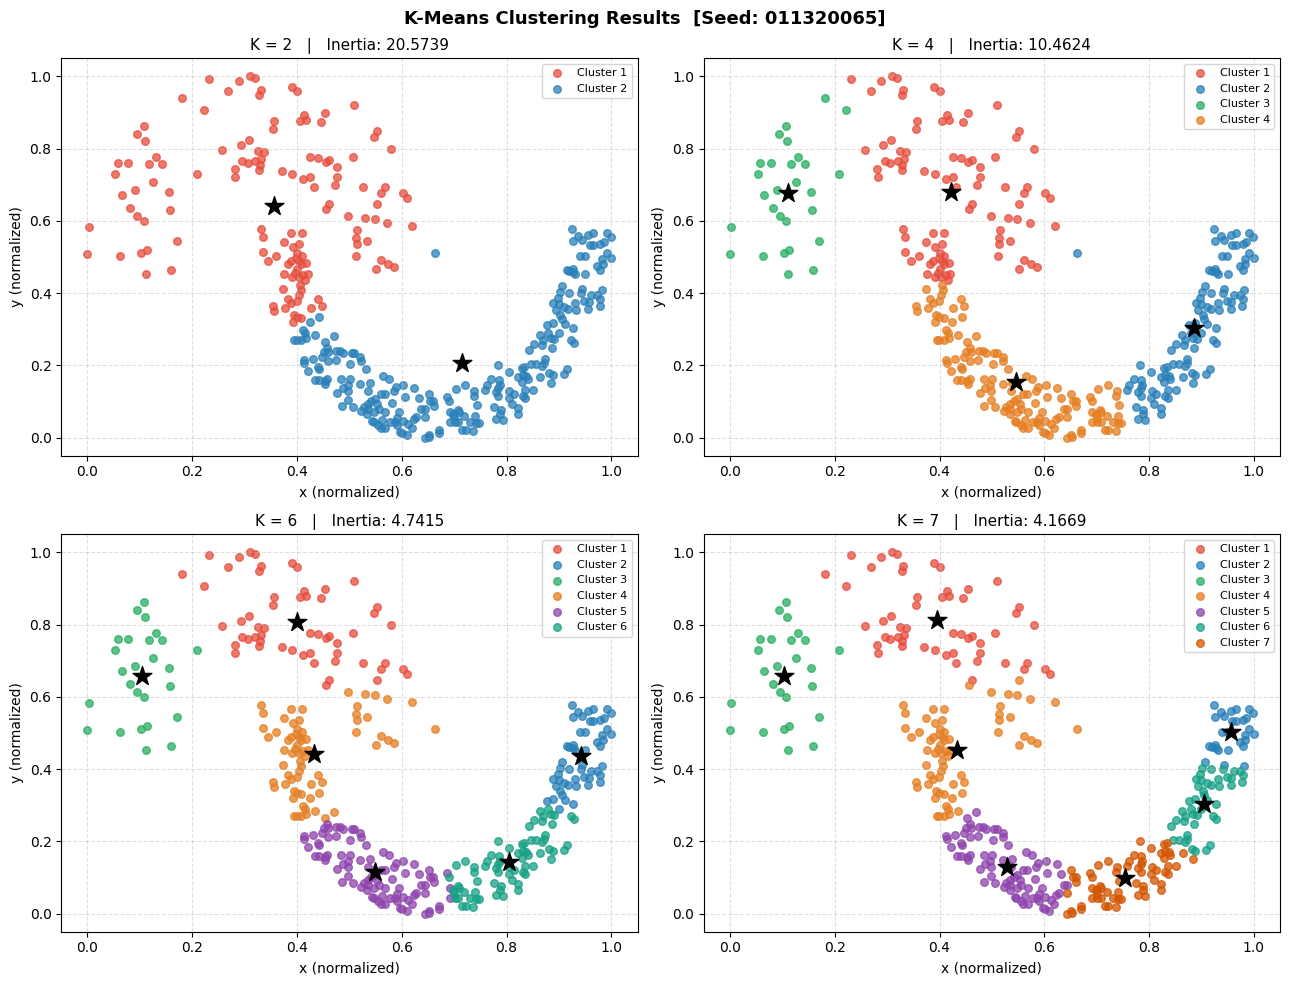

Plot saved as kmeans_clusters.png


In [16]:
clr = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22',
       '#8e44ad', '#16a085', '#d35400']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
flat_ax = axes.ravel()

for i, K in enumerate(k_values):
    ax = flat_ax[i]
    cls = results[K]['clusters']
    cnt = results[K]['centers']

    for k in range(K):
        if len(cls[k]) > 0:
            pts = np.array(cls[k])
            ax.scatter(pts[:, 0], pts[:, 1], c=clr[k], s=30,
                       alpha=0.75, label=f'Cluster {k+1}')

    # plot centers as black stars
    for c in cnt:
        ax.scatter(c[0], c[1], c='black', marker='*', s=200, zorder=6)

    ax.set_title(f'K = {K}   |   Inertia: {results[K]["inertia"]:.4f}', fontsize=11)
    ax.set_xlabel('x (normalized)')
    ax.set_ylabel('y (normalized)')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('K-Means Clustering Results  [Seed: 011320065]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()
print('Plot saved as kmeans_clusters.png')

## Step 8 — Inertia Table and Elbow Curve

   K         Inertia
----------------------
   2       20.573931
   4        8.497120
   6        4.694852
   7        3.656628


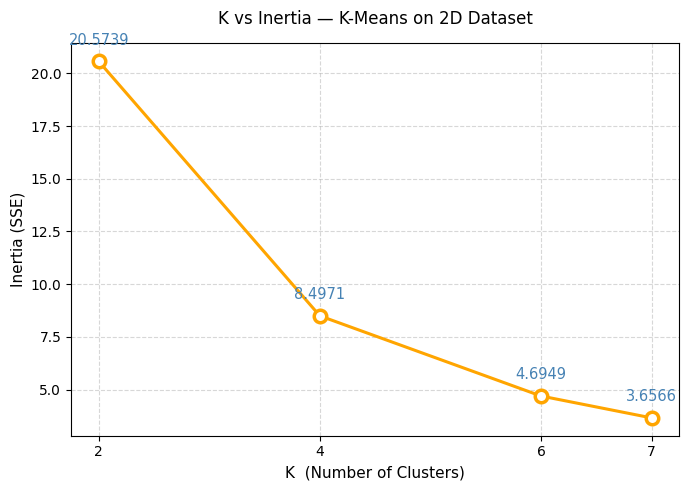

Plot saved as kmeans_elbow.png


In [8]:
print(f"{'K':>4}  {'Inertia':>14}")
print("-" * 22)
for K in k_values:
    print(f"{K:>4}  {results[K]['inertia']:>14.6f}")

# ---- Elbow Curve ----
inertia_vals = [results[K]['inertia'] for K in k_values]

plt.figure(figsize=(7, 5))

plt.plot(k_values, inertia_vals, marker='o', color='orange',
         linewidth=2.2, markersize=9, markerfacecolor='white',
         markeredgewidth=2.5)

for K, val in zip(k_values, inertia_vals):
    plt.annotate(f'{val:.4f}',
                 xy=(K, val),
                 xytext=(0, 12),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10.5,
                 color='steelblue')

plt.title('K vs Inertia — K-Means on 2D Dataset', fontsize=12, pad=14)
plt.xlabel('K  (Number of Clusters)', fontsize=11)
plt.ylabel('Inertia (SSE)', fontsize=11)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()
print('Plot saved as kmeans_elbow.png')